In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from src.data.load_data import load_data
from src.data.data_split import split_data_with_stratification
from src.data.preprocess import preprocess_data
from src.features.features_engineer import engineer_features

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [4]:
df_raw = load_data()
df_raw

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [5]:
df = preprocess_data(df_raw)
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,0,15.23,2,Allowed_With_Citation,2,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,0,12.55,4,Allowed_With_Citation,4,100.00,Medium


In [6]:
df = engineer_features(df)
X_train, X_test, y_train, y_test = split_data_with_stratification(df)

print(f"Training: {X_train.shape}")
print(f"Testing: {X_test.shape}")

Training: (39200, 28)
Testing: (9800, 28)


In [7]:
X_train.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,Total_Effort_Hours,GenAI_to_Traditional_Ratio,...,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
48130,3.662,12.09,3,1,13.63,5,3,100.00,25.72,0.887014,...,0,1,0,0,1,0,0,0,0,0
41346,3.671,0.42,3,1,11.28,4,1,91.86,11.70,0.037234,...,0,1,0,0,1,0,0,0,1,0
16745,3.388,4.67,3,0,18.18,2,3,74.75,22.85,0.256876,...,0,0,0,1,0,0,1,0,1,0
21024,3.630,13.16,3,0,14.00,4,7,70.70,27.16,0.940000,...,0,0,0,1,0,1,0,0,0,1
31185,1.770,1.66,1,0,17.03,1,4,68.24,18.69,0.097475,...,0,0,1,0,1,0,0,0,0,1


In [8]:
y_train

48130    0
41346    1
16745    0
21024    2
31185    1
        ..
7151     2
16936    0
2449     0
4082     2
36967    0
Name: Burnout_Risk_Level_Enc, Length: 39200, dtype: int64

In [9]:
burnout_order = ["Low", "Medium", "High"]

In [10]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average="macro")

print(f"Logistic Regression — Accuracy: {lr_acc:.4f}, Macro F1: {lr_f1:.4f}")
print(classification_report(y_test, lr_preds, target_names=burnout_order))

Logistic Regression — Accuracy: 0.5072, Macro F1: 0.5082
              precision    recall  f1-score   support

         Low       0.50      0.67      0.58      3273
      Medium       0.52      0.31      0.39      4208
        High       0.50      0.63      0.56      2319

    accuracy                           0.51      9800
   macro avg       0.51      0.54      0.51      9800
weighted avg       0.51      0.51      0.49      9800



/Users/ampjee/Documents/PracticalMachineLearning/ai-impact-on-students-project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
import lightgbm as lgb

lgbm_baseline = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm_baseline.fit(X_train, y_train)

lgbm_preds = lgbm_baseline.predict(X_test)
lgbm_acc = accuracy_score(y_test, lgbm_preds)
lgbm_f1 = f1_score(y_test, lgbm_preds, average="macro")

print(f"LightGBM Baseline — Accuracy: {lgbm_acc:.4f}, Macro F1: {lgbm_f1:.4f}")
print(classification_report(y_test, lgbm_preds, target_names=burnout_order))

LightGBM Baseline — Accuracy: 0.5072, Macro F1: 0.5114
              precision    recall  f1-score   support

         Low       0.50      0.64      0.56      3273
      Medium       0.50      0.35      0.41      4208
        High       0.52      0.61      0.56      2319

    accuracy                           0.51      9800
   macro avg       0.51      0.53      0.51      9800
weighted avg       0.51      0.51      0.50      9800



In [12]:
lgbm_tuned = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
)
lgbm_tuned.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=50)],
)

lgbm_tuned_preds = lgbm_tuned.predict(X_test)
lgbm_tuned_acc = accuracy_score(y_test, lgbm_tuned_preds)
lgbm_tuned_f1 = f1_score(y_test, lgbm_tuned_preds, average="macro")

print(f"LightGBM Tuned — Accuracy: {lgbm_tuned_acc:.4f}, Macro F1: {lgbm_tuned_f1:.4f}")
print(f"Best iteration: {lgbm_tuned.best_iteration_}")
print(classification_report(y_test, lgbm_tuned_preds, target_names=burnout_order))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[138]	valid_0's multi_logloss: 0.945557
LightGBM Tuned — Accuracy: 0.5122, Macro F1: 0.5160
Best iteration: 138
              precision    recall  f1-score   support

         Low       0.51      0.65      0.57      3273
      Medium       0.51      0.35      0.42      4208
        High       0.52      0.61      0.56      2319

    accuracy                           0.51      9800
   macro avg       0.51      0.54      0.52      9800
weighted avg       0.51      0.51      0.50      9800



In [13]:
comparison = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "LightGBM Baseline", "LightGBM Tuned"],
        "Accuracy": [lr_acc, lgbm_acc, lgbm_tuned_acc],
        "Macro F1": [lr_f1, lgbm_f1, lgbm_tuned_f1],
    }
)
comparison

,Model,Accuracy,Macro F1
0,Logistic Regression,0.507245,0.508227
1,LightGBM Baseline,0.507245,0.511441
2,LightGBM Tuned,0.512245,0.515962


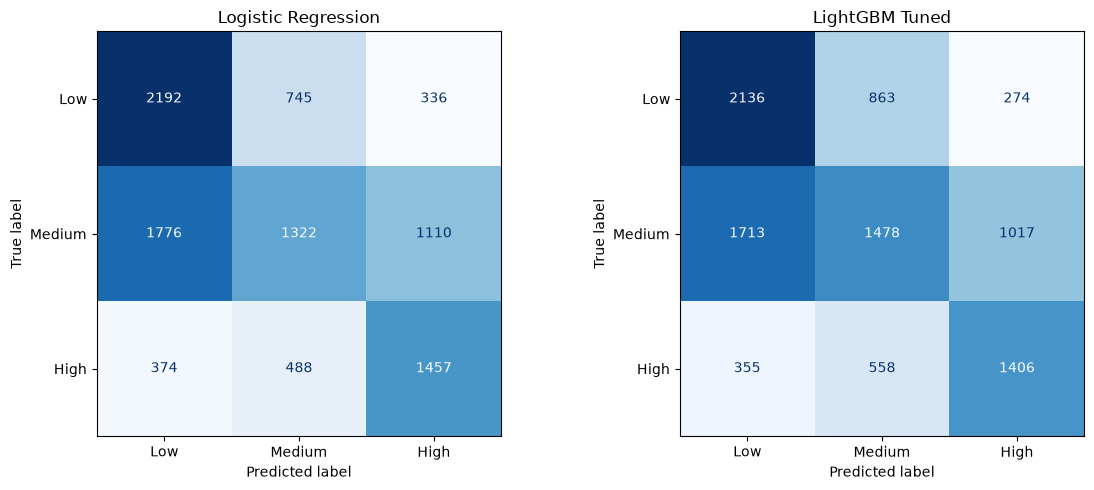

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(
    axes, [lr_preds, lgbm_tuned_preds], ["Logistic Regression", "LightGBM Tuned"]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=burnout_order).plot(
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [15]:
X_train_fe, X_test_fe = X_train, X_test
print(f"Features: {X_train_fe.shape[1]}")

Features: 28


In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        objective="multiclass",
        num_class=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    ),
    "CatBoost": CatBoostClassifier(
        loss_function="MultiClass",
        random_state=42,
        verbose=0,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
fitted_models = {}

for name, model in models.items():
    cv_f1 = cross_val_score(
        model, X_train_fe, y_train, cv=cv, scoring="f1_macro"
    ).mean()
    model.fit(X_train_fe, y_train)
    preds = model.predict(X_test_fe).ravel().astype(int)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results.append(
        {"Model": name, "CV Macro F1": cv_f1, "Accuracy": acc, "Macro F1": f1}
    )
    fitted_models[name] = model
    print(f"{name:<20} CV F1: {cv_f1:.4f}  Test Acc: {acc:.4f}  Test F1: {f1:.4f}")

results_df = (
    pd.DataFrame(results)
    .sort_values("CV Macro F1", ascending=False)
    .reset_index(drop=True)
)
results_df

Logistic Regression  CV F1: 0.4980  Test Acc: 0.5088  Test F1: 0.5099
Random Forest        CV F1: 0.5031  Test Acc: 0.5123  Test F1: 0.5157
LightGBM             CV F1: 0.5029  Test Acc: 0.5072  Test F1: 0.5114
XGBoost              CV F1: 0.5054  Test Acc: 0.5119  Test F1: 0.5110
CatBoost             CV F1: 0.5082  Test Acc: 0.5176  Test F1: 0.5159


,Model,CV Macro F1,Accuracy,Macro F1
0,CatBoost,0.508166,0.517551,0.515931
1,XGBoost,0.505416,0.511939,0.510984
2,Random Forest,0.503097,0.512347,0.515732
3,LightGBM,0.502886,0.507245,0.511441
4,Logistic Regression,0.497951,0.508776,0.509915


In [17]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


# def objective(trial):
#     params = {
#         "objective": "multiclass", "num_class": 3, "class_weight": "balanced",
#         "random_state": 42, "n_jobs": -1, "verbose": -1,
#         "n_estimators": trial.suggest_int("n_estimators", 200, 800),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 15, 127),
#         "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#     }
#     model = lgb.LGBMClassifier(**params)
#     return cross_val_score(model, X_train_fe, y_train, cv=cv, scoring="f1_macro").mean()


# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30)
# print(f"Best CV Macro F1: {study.best_value:.4f}")
# print("Best params:", study.best_params)

best_params = {
    "objective": "multiclass",
    "num_class": 3,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
    "n_estimators": 568,
    "learning_rate": 0.012595671143611863,
    "num_leaves": 84,
    "min_child_samples": 22,
    "subsample": 0.9218542362585128,
    "colsample_bytree": 0.6195855297210976,
}
lgbm_optuna = lgb.LGBMClassifier(**best_params)
lgbm_optuna.fit(X_train_fe, y_train)

lgbm_optuna_preds = lgbm_optuna.predict(X_test_fe)
lgbm_optuna_acc = accuracy_score(y_test, lgbm_optuna_preds)
lgbm_optuna_f1 = f1_score(y_test, lgbm_optuna_preds, average="macro")
print(
    f"Tuned LightGBM — Accuracy: {lgbm_optuna_acc:.4f}, Macro F1: {lgbm_optuna_f1:.4f}"
)
print(classification_report(y_test, lgbm_optuna_preds, target_names=burnout_order))

/Users/ampjee/Documents/PracticalMachineLearning/ai-impact-on-students-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tuned LightGBM — Accuracy: 0.5136, Macro F1: 0.5180
              precision    recall  f1-score   support

         Low       0.51      0.65      0.57      3273
      Medium       0.51      0.37      0.43      4208
        High       0.53      0.59      0.56      2319

    accuracy                           0.51      9800
   macro avg       0.52      0.54      0.52      9800
weighted avg       0.51      0.51      0.51      9800



In [18]:
import catboost
from sklearn.model_selection import StratifiedKFold, cross_val_score


optuna.logging.set_verbosity(optuna.logging.WARNING)


# def objective(trial):
#     params = {
#         "loss_function": "MultiClass",
#         "auto_class_weights": "Balanced",
#         "random_state": 42,
#         "verbose": 0,
#         "iterations": trial.suggest_int("iterations", 200, 800),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "depth": trial.suggest_int("depth", 4, 10),
#         "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
#     }
#     model = catboost.CatBoostClassifier(**params)
#     return cross_val_score(model, X_train_fe, y_train, cv=cv, scoring="f1_macro").mean()


# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30, show_progress_bar=True)
# print(f"Best CV Macro F1: {study.best_value:.4f}")
# print("Best params:", study.best_params)

best_params = {
    "loss_function": "MultiClass",
    "auto_class_weights": "Balanced",
    "random_state": 42,
    "verbose": 0,
    "iterations": 762,
    "learning_rate": 0.028080429751454198,
    "depth": 10,
    "l2_leaf_reg": 3.0133326241218543,
}
catboost_optuna = catboost.CatBoostClassifier(**best_params)
catboost_optuna.fit(X_train_fe, y_train)

catboost_optuna_preds = catboost_optuna.predict(X_test_fe)
catboost_optuna_acc = accuracy_score(y_test, catboost_optuna_preds)
catboost_optuna_f1 = f1_score(y_test, catboost_optuna_preds, average="macro")
print(
    f"Tuned CatBoost — Accuracy: {catboost_optuna_acc:.4f}, Macro F1: {catboost_optuna_f1:.4f}"
)
print(classification_report(y_test, catboost_optuna_preds, target_names=burnout_order))

Tuned CatBoost — Accuracy: 0.5074, Macro F1: 0.5122
              precision    recall  f1-score   support

         Low       0.50      0.63      0.56      3273
      Medium       0.50      0.37      0.42      4208
        High       0.52      0.58      0.55      2319

    accuracy                           0.51      9800
   macro avg       0.51      0.53      0.51      9800
weighted avg       0.51      0.51      0.50      9800



In [19]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import xgboost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def objective(trial):
#     params = {
#         "objective": "multi:softprob",
#         "num_class": 3,
#         "random_state": 42,
#         "n_jobs": -1,
#         "verbosity": 0,
#         "n_estimators": trial.suggest_int("n_estimators", 200, 800),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
#     }
#     model = XGBClassifier(**params)
#     return cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro").mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print("Best Macro F1:", study.best_value)
# print("Best params:", study.best_params)

best_params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": 0,
    "n_estimators": 370,
    "learning_rate": 0.03275494231675825,
    "max_depth": 3,
    "min_child_weight": 1,
    "subsample": 0.8995177458059798,
    "colsample_bytree": 0.6003744287092915,
    "reg_alpha": 0.19136141848829258,
    "reg_lambda": 4.1037113192886325,
}

xgboost_optuna = xgboost.XGBClassifier(**best_params)
xgboost_optuna.fit(X_train_fe, y_train)

xgboost_optuna_preds = xgboost_optuna.predict(X_test_fe)
xgboost_optuna_acc = accuracy_score(y_test, xgboost_optuna_preds)
xgboost_optuna_f1 = f1_score(y_test, xgboost_optuna_preds, average="macro")
print(
    f"Tuned XGBoost — Accuracy: {xgboost_optuna_acc:.4f}, Macro F1: {xgboost_optuna_f1:.4f}"
)
print(classification_report(y_test, xgboost_optuna_preds, target_names=burnout_order))

Tuned XGBoost — Accuracy: 0.5299, Macro F1: 0.5275
              precision    recall  f1-score   support

         Low       0.54      0.49      0.51      3273
      Medium       0.49      0.61      0.54      4208
        High       0.66      0.44      0.53      2319

    accuracy                           0.53      9800
   macro avg       0.56      0.51      0.53      9800
weighted avg       0.54      0.53      0.53      9800



In [20]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ("lgbm", lgbm_optuna),
    ("rf", fitted_models["Random Forest"]),
    ("cat", catboost_optuna),
    ("xg", xgboost_optuna),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=cv,
    n_jobs=-1,
)
stack.fit(X_train_fe, y_train)

stack_preds = stack.predict(X_test_fe)
stack_acc = accuracy_score(y_test, stack_preds)
stack_f1 = f1_score(y_test, stack_preds, average="macro")

print(f"Stacking — Accuracy: {stack_acc:.4f}, Macro F1: {stack_f1:.4f}")
print(classification_report(y_test, stack_preds, target_names=burnout_order))

Stacking — Accuracy: 0.5114, Macro F1: 0.5137
              precision    recall  f1-score   support

         Low       0.50      0.68      0.58      3273
      Medium       0.51      0.32      0.40      4208
        High       0.52      0.61      0.57      2319

    accuracy                           0.51      9800
   macro avg       0.51      0.54      0.51      9800
weighted avg       0.51      0.51      0.50      9800



In [21]:
final = (
    pd.concat(
        [
            results_df[["Model", "Accuracy", "Macro F1"]],
            pd.DataFrame(
                [
                    {
                        "Model": "Tuned LightGBM",
                        "Accuracy": lgbm_optuna_acc,
                        "Macro F1": lgbm_optuna_f1,
                    },
                    {
                        "Model": "Tuned CatBoost",
                        "Accuracy": catboost_optuna_acc,
                        "Macro F1": catboost_optuna_f1,
                    },
                    {
                        "Model": "Tuned XGBoost",
                        "Accuracy": xgboost_optuna_acc,
                        "Macro F1": xgboost_optuna_f1,
                    },
                    {"Model": "Stacking", "Accuracy": stack_acc, "Macro F1": stack_f1},
                ]
            ),
        ],
        ignore_index=True,
    )
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)
display(final)

,Model,Accuracy,Macro F1
0,Tuned XGBoost,0.529898,0.527491
1,Tuned LightGBM,0.513571,0.517983
2,CatBoost,0.517551,0.515931
3,Random Forest,0.512347,0.515732
4,Stacking,0.511429,0.513711
5,Tuned CatBoost,0.507449,0.512159
6,LightGBM,0.507245,0.511441
7,XGBoost,0.511939,0.510984
8,Logistic Regression,0.508776,0.509915


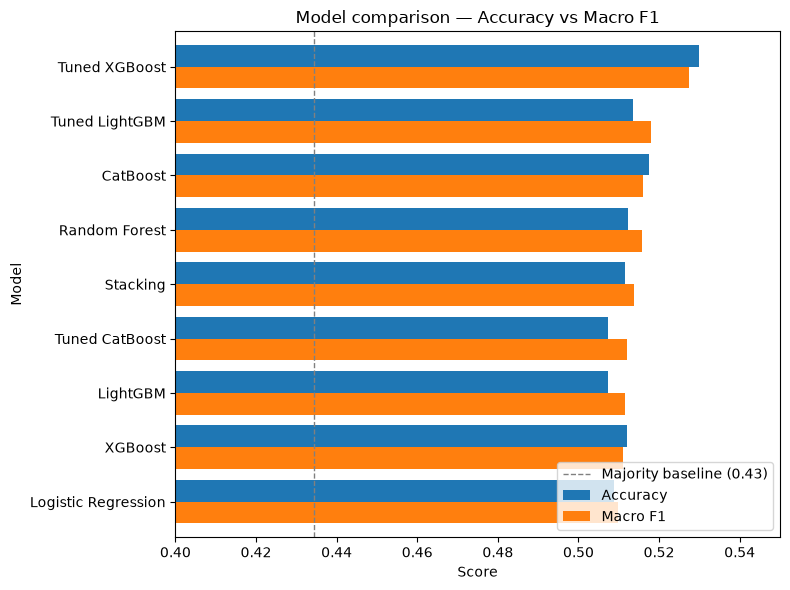

In [22]:
# Plot the model comparison (Accuracy vs Macro F1)
ax = final.set_index("Model")[["Accuracy", "Macro F1"]].plot.barh(
    figsize=(8, 6), width=0.8
)
ax.axvline(
    0.4343, color="grey", linestyle="--", linewidth=1, label="Majority baseline (0.43)"
)
ax.set_xlabel("Score")
ax.set_xlim(0.40, 0.55)
ax.set_title("Model comparison — Accuracy vs Macro F1")
ax.invert_yaxis()  # best model on top
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [23]:
import shap

explainer = shap.TreeExplainer(xgboost_optuna)
shap_values = explainer.shap_values(X_test_fe)

# shape: (n_samples, n_features, n_classes)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (9800, 28, 3)


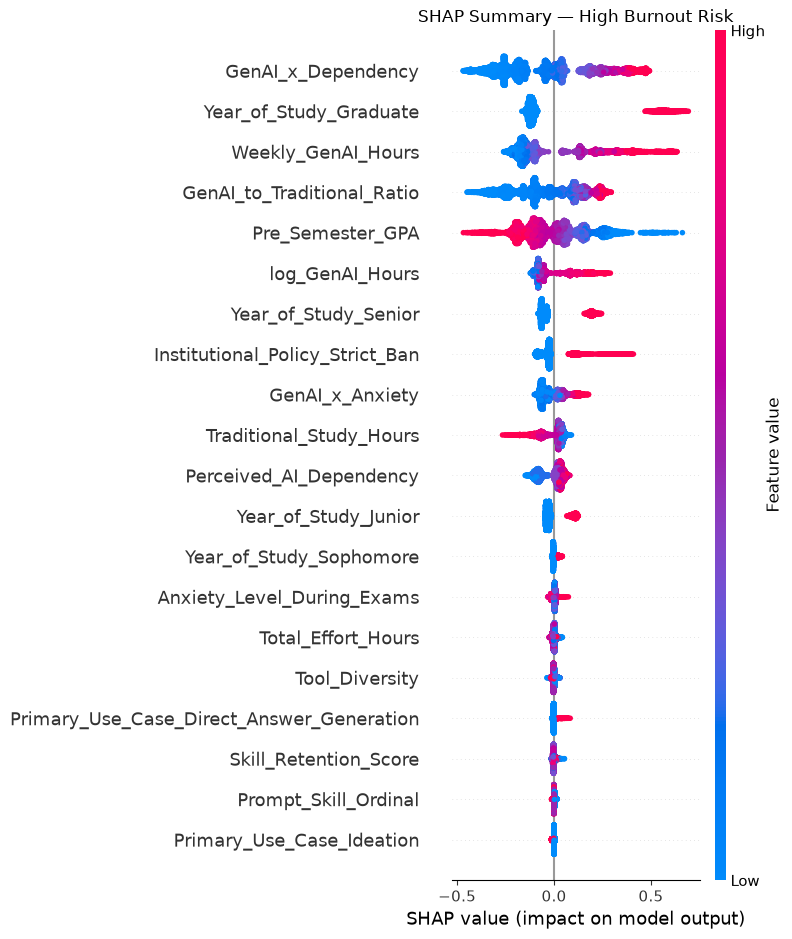

In [24]:
class_idx = burnout_order.index("High")

# shap_values has shape (n_samples, n_features, n_classes); slice the class axis
shap_high = shap_values[:, :, class_idx]

plt.figure()
shap.summary_plot(shap_high, X_test_fe, show=False)
plt.title("SHAP Summary — High Burnout Risk")
plt.tight_layout()
plt.show()

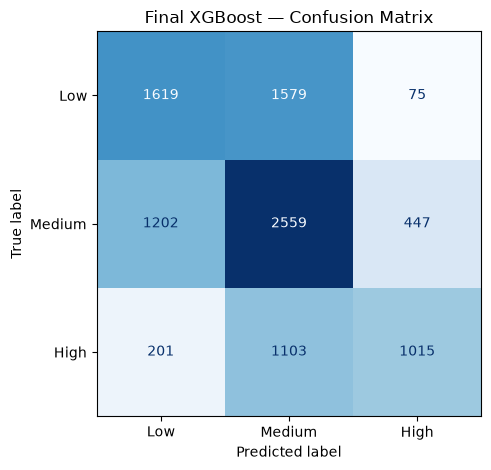

In [25]:
# Final XGBoost — confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgboost_optuna_preds)
ConfusionMatrixDisplay(cm, display_labels=burnout_order).plot(
    cmap="Blues", colorbar=False
)
plt.title("Final XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

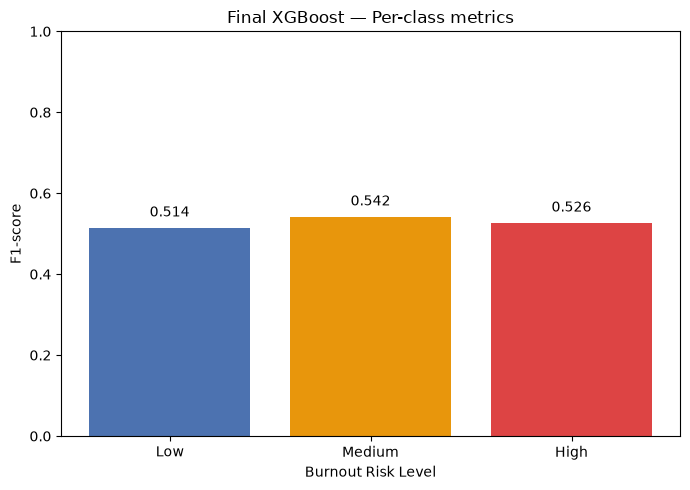

In [26]:
from sklearn.metrics import f1_score

final_f1_per_class = f1_score(y_test, xgboost_optuna_preds, average=None)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    burnout_order, final_f1_per_class, color=["#4C72B0", "#E8960C", "#DD4444"]
)

for bar, score in zip(bars, final_f1_per_class):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Final XGBoost — Per-class metrics")
ax.set_ylabel("F1-score")
ax.set_xlabel("Burnout Risk Level")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()